<a href="https://colab.research.google.com/github/aHawkins63/Feature-Engineering/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple MNIST


Image Data Shape (1797, 64)


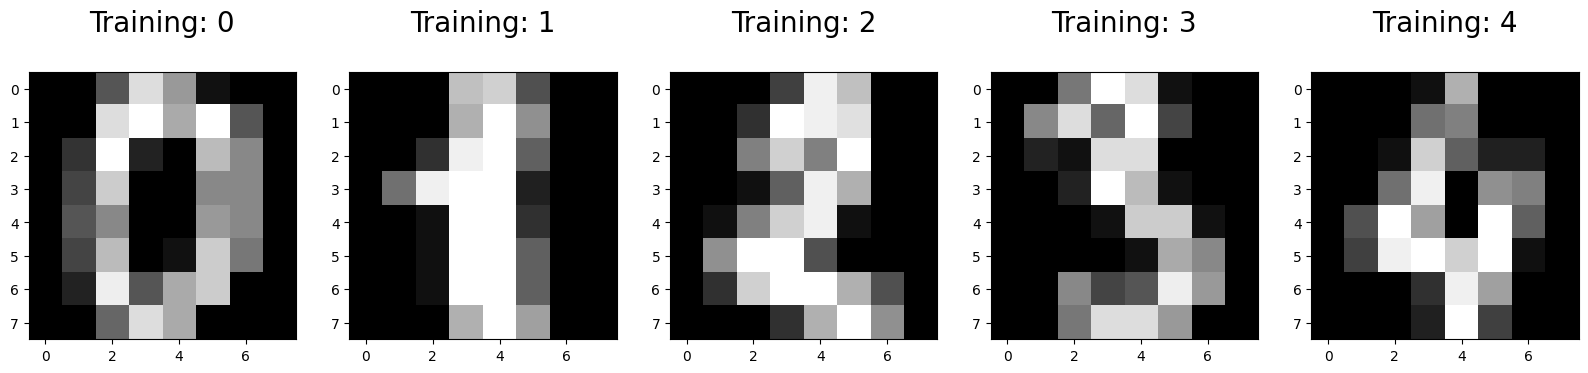

2


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[2]
[2 8 2 6 6 7 1 9 8 5]
0.9511111111111111


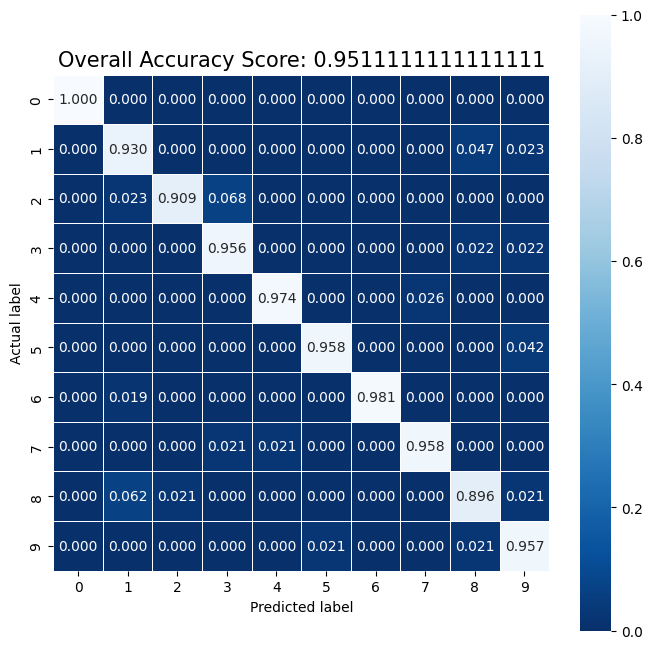

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

digits = load_digits()

# Print to show there are 1797 images (8 by 8 images for a dimensionality of 64)
print("Image Data Shape" , digits.data.shape)

# showing the images and the labels
plt.figure(figsize=(20,4))
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title('Training: %i\n' % label, fontsize = 20)
plt.show()

# split the data into a training and test set
image_train, image_test, trueNum_train, trueNum_test = train_test_split(digits.data,
                                                                        digits.target,
                                                                        test_size=0.25,
                                                                        random_state=0)
print(trueNum_test[0])

# make an instance of the model
logisticRegr = LogisticRegression()

# train the model on the data (model learns the relationship btwn the image and true number)
logisticRegr.fit(image_train, trueNum_train)

# using this trained model, predict the labels of the test set
# returns a numpy array
# predict for 1 obs
singlePrediction = logisticRegr.predict(image_test[0].reshape(1, -1))
print(singlePrediction)

# predict multiple
multPredictions = logisticRegr.predict(image_test[0:10])
print(multPredictions)

# predict the entire test set
fullPrediction = logisticRegr.predict(image_test)

# measuring model performance
# accuracy as fraction of correct predictions
# calculated by correct predictions/total number of predictions
# this can be done using the score method
score = logisticRegr.score(image_test, trueNum_test)
print(score)

# we can also use a confusion matrix to visualize the performance of a classification model
cm = metrics.confusion_matrix(trueNum_test, fullPrediction)
# use this line to normalize the confusion matrix to show percentages instead of counts
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot this matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Overall Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);
plt.savefig('toy_Digits_ConfusionSeabornCodementor.png')
plt.show();

## Support Vector Machine (SVM)

SVM Accuracy Score: 0.9955555555555555


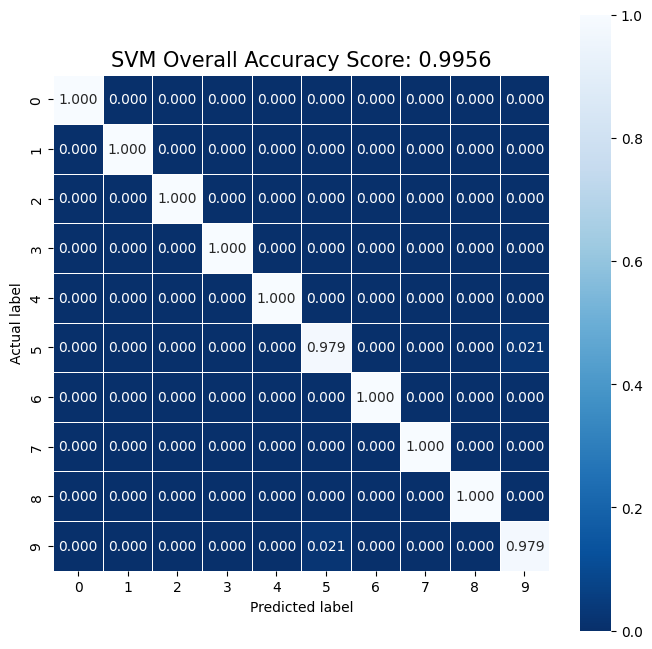

In [6]:
from sklearn import svm

# Make an instance of the SVM model
svm_model = svm.SVC(gamma=0.001)

# Train the model
svm_model.fit(image_train, trueNum_train)

# Predict the entire test set
svm_fullPrediction = svm_model.predict(image_test)

# Measuring model performance
svm_score = svm_model.score(image_test, trueNum_test)
print(f"SVM Accuracy Score: {svm_score}")

# Confusion matrix
svm_cm = metrics.confusion_matrix(trueNum_test, svm_fullPrediction)
svm_cm = svm_cm.astype('float') / svm_cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(svm_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
svm_title = f'SVM Overall Accuracy Score: {svm_score:.4f}';
plt.title(svm_title, size = 15);
plt.show();

## Naive Bayes (Gaussian Naive Bayes)

Naive Bayes Accuracy Score: 0.8333333333333334


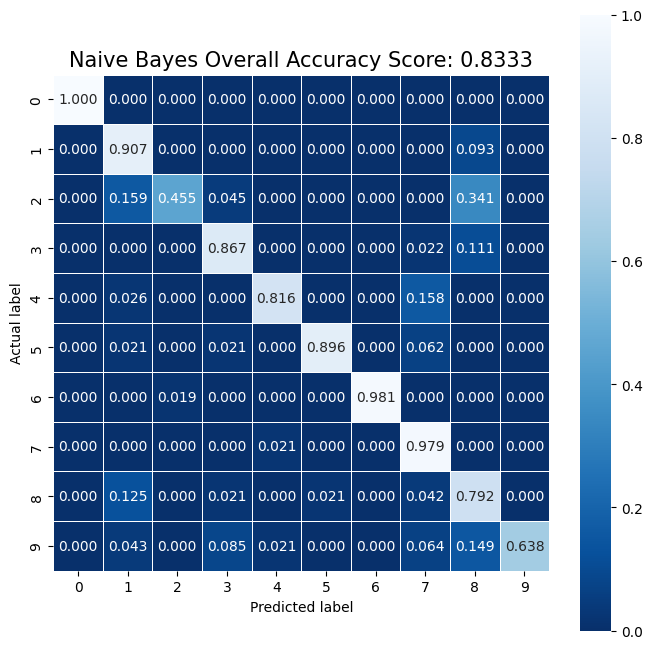

In [7]:
from sklearn.naive_bayes import GaussianNB

# Make an instance of the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(image_train, trueNum_train)

# Predict the entire test set
nb_fullPrediction = nb_model.predict(image_test)

# Measuring model performance
nb_score = nb_model.score(image_test, trueNum_test)
print(f"Naive Bayes Accuracy Score: {nb_score}")

# Confusion matrix
nb_cm = metrics.confusion_matrix(trueNum_test, nb_fullPrediction)
nb_cm = nb_cm.astype('float') / nb_cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(nb_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
nb_title = f'Naive Bayes Overall Accuracy Score: {nb_score:.4f}';
plt.title(nb_title, size = 15);
plt.show();

## Decision Tree Classifier

Decision Tree Accuracy Score: 0.8377777777777777


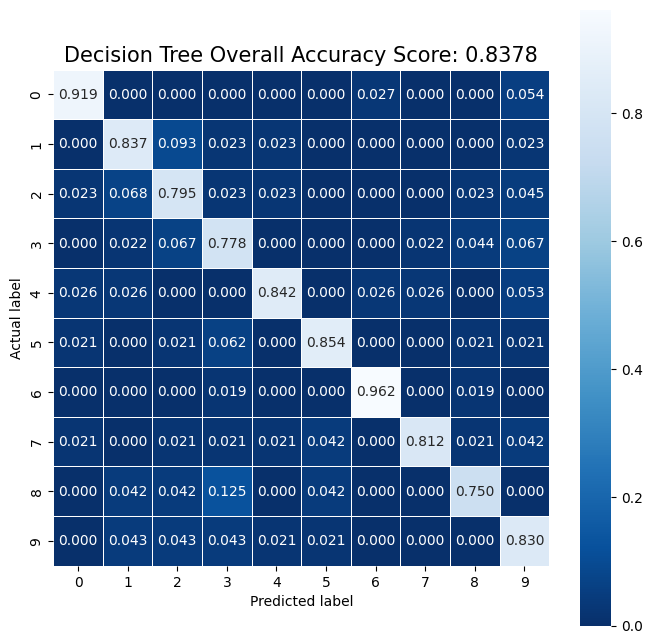

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Make an instance of the Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=0)

# Train the model
dt_model.fit(image_train, trueNum_train)

# Predict the entire test set
dt_fullPrediction = dt_model.predict(image_test)

# Measuring model performance
dt_score = dt_model.score(image_test, trueNum_test)
print(f"Decision Tree Accuracy Score: {dt_score}")

# Confusion matrix
dt_cm = metrics.confusion_matrix(trueNum_test, dt_fullPrediction)
dt_cm = dt_cm.astype('float') / dt_cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(dt_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
dt_title = f'Decision Tree Overall Accuracy Score: {dt_score:.4f}';
plt.title(dt_title, size = 15);
plt.show();

MNIST with